# RF-DETR — Pretrained Model Showcase

## Table of Contents
1. [What is RF-DETR?](#what-is-rf-detr)
2. [Setup](#setup)
3. [Model Variants](#model-variants)
4. [Loading a Pretrained Model](#loading-a-pretrained-model)
5. [Inference on LARS Images](#inference-on-lars-images)
6. [Inference Parameters](#inference-parameters)
7. [Architecture Overview](#architecture-overview)
8. [Fine-Tuning Parameters](#fine-tuning-parameters)
9. [Dataset Preparation for Fine-Tuning](#dataset-preparation-for-fine-tuning)

## What is RF-DETR?

**RF-DETR** (Roboflow Detection Transformer) is a real-time object detection model released by Roboflow in 2025. Key properties:

- **Architecture**: DINOv2 Vision Transformer backbone + deformable-attention decoder
- **End-to-end**: no NMS required — Hungarian matching at train time, top-k selection at inference
- **COCO pretrained**: ships with weights trained on COCO 2017 (80 classes)
- **Two sizes**: `RFDETRBase` (~29 M params) and `RFDETRLarge` (~128 M params)
- **Fine-tunable**: the pretrained weights transfer well to custom datasets with relatively few epochs

> **Note**: The pretrained model outputs COCO categories (e.g. `boat`, `person`). To detect LARS-specific categories (Buoy, Float, etc.) the model must be fine-tuned on our processed dataset.

## Setup

Install the `rfdetr` package (not in `requirements.txt` yet — add it once confirmed):

```bash
python3.11 -m pip install rfdetr supervision
```

`supervision` is a Roboflow utility library used for annotation drawing and is pulled in automatically as a dependency of `rfdetr`, but installing it explicitly ensures the right version.

In [3]:
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import supervision as sv
from rfdetr import RFDETRBase, RFDETRLarge
from rfdetr.util.coco_classes import COCO_CLASSES

DATA_ROOT = Path("../Data/lars_processed")

## Model Variants

| Variant | Backbone | Params | Default resolution | COCO AP |
|---|---|---|---|---|
| `RFDETRBase` | DINOv2-Small (ViT-S) | ~29 M | 560 px | ~53 |
| `RFDETRLarge` | DINOv2-Base (ViT-B) | ~128 M | 560 px | ~56 |

For the maritime detection task, **`RFDETRBase`** is the practical starting point — it trains faster and the accuracy gap to Large is small for domain-specific fine-tuning.

## Loading a Pretrained Model

Calling the constructor without arguments downloads the COCO-pretrained weights automatically (cached after first download).

In [4]:
# Load RF-DETR Base with COCO pretrained weights
model = RFDETRBase()


[2026-04-06 19:31:02] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-04-06 19:31:03] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.


In [5]:
print(dir(model))

['__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_align_num_classes_from_dataset', '_detect_num_classes_for_training', '_has_warned_about_not_being_optimized_for_inference', '_is_optimized_for_inference', '_load_classes', '_model_config_class', '_optimized_batch_size', '_optimized_dtype', '_optimized_has_been_compiled', '_optimized_resolution', '_resolve_trainer_device_kwargs', '_train_config_class', 'callbacks', 'class_names', 'deploy_to_roboflow', 'export', 'get_model', 'get_model_config', 'get_train_config', 'maybe_download_pretrain_weights', 'means', 'model', 'model_config', 'optimize_for_inference', 'predict', 'remove_optimized_model', 'size', 'stds', 'train']


## Inference on LARS Images

Run the pretrained COCO model on a handful of images from our processed training set.
Since the model was not trained on LARS categories, expect it to fire on `boat` and `person` for some objects while missing domain-specific ones (buoys, floats).

[2026-04-06 19:31:04] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().
`use_return_dict` is deprecated! Use `return_dict` instead!


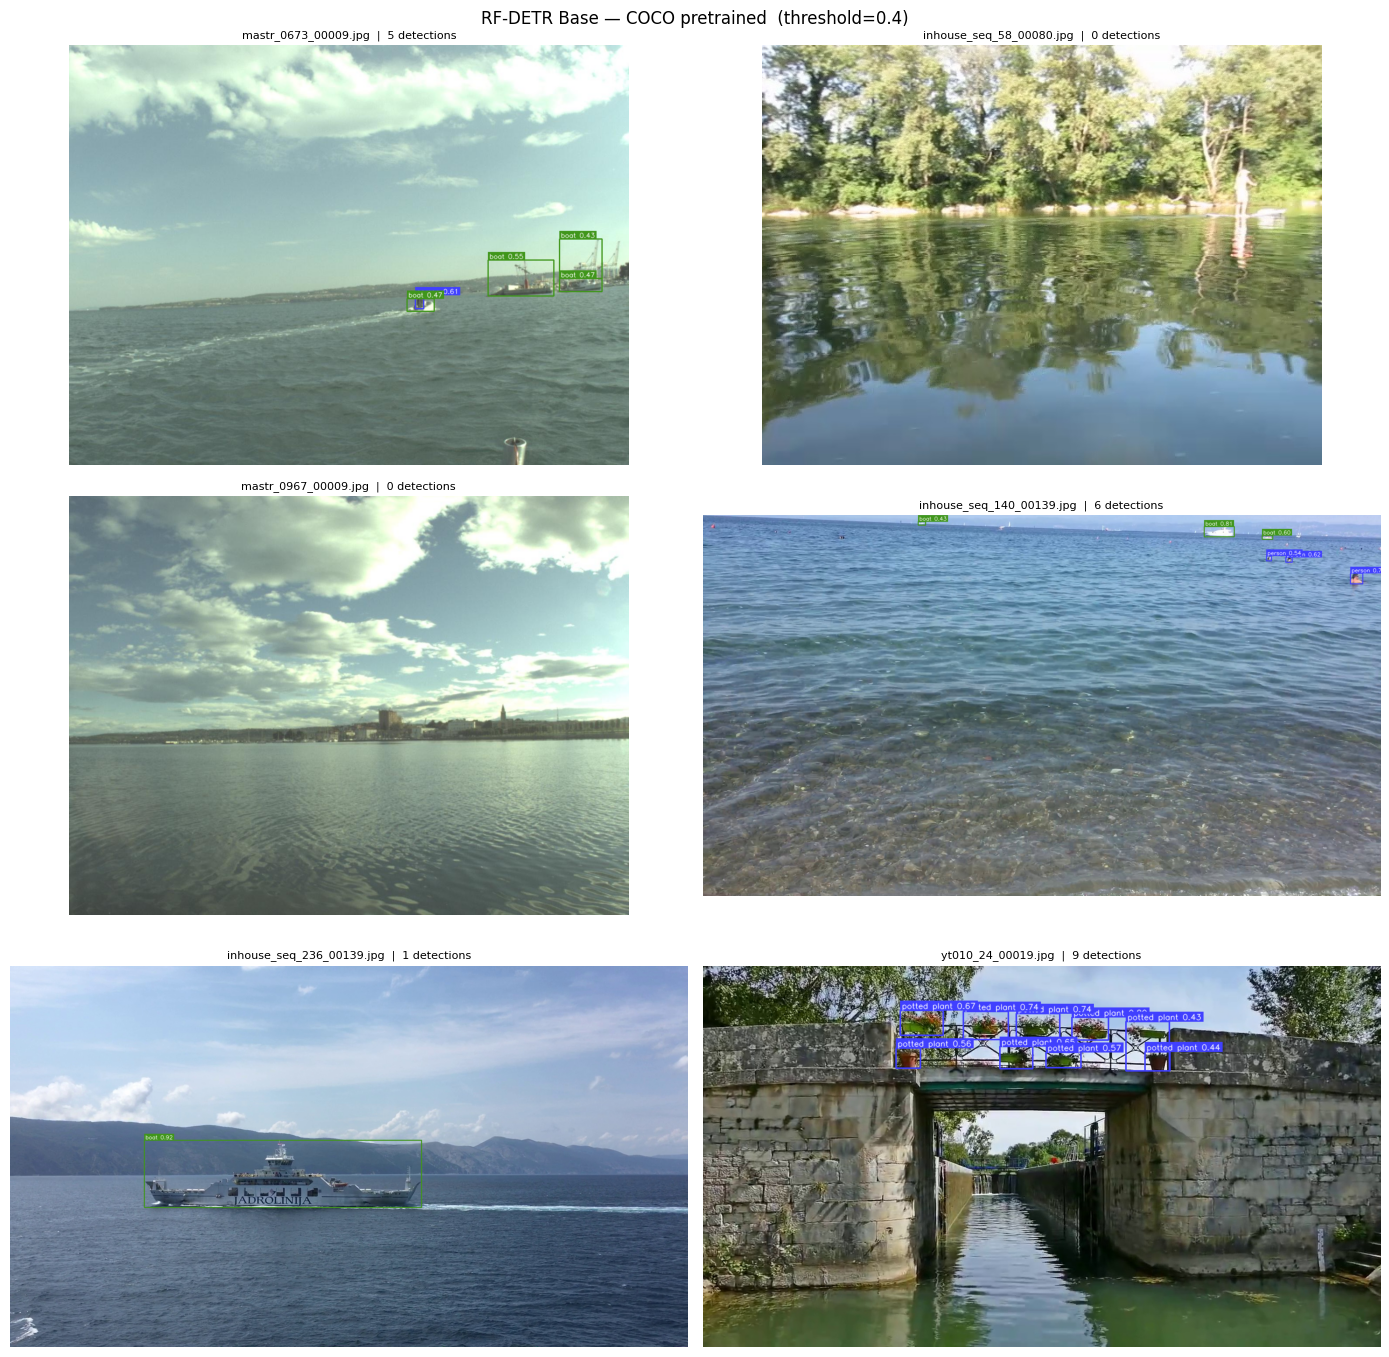

In [6]:
# Sample a few images from the processed train split
img_dir = DATA_ROOT / "train" / "images"
all_imgs = sorted(img_dir.glob("*.jpg"))

random.seed(7)
sample_paths = random.sample(all_imgs, 6)

THRESHOLD = 0.4

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

box_annotator   = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_scale=0.5, text_padding=3)

for ax, img_path in zip(axes.flat, sample_paths):
    pil_img = Image.open(img_path).convert("RGB")
    detections = model.predict(pil_img, threshold=THRESHOLD)

    labels = [
        f"{COCO_CLASSES[cid]} {conf:.2f}"
        for cid, conf in zip(detections.class_id, detections.confidence)
    ]

    img_ann = box_annotator.annotate(np.array(pil_img).copy(), detections)
    img_ann = label_annotator.annotate(img_ann, detections, labels=labels)

    ax.imshow(img_ann)
    ax.set_title(f"{img_path.name}  |  {len(detections)} detections", fontsize=8)
    ax.axis("off")

plt.suptitle(f"RF-DETR Base — COCO pretrained  (threshold={THRESHOLD})", fontsize=12)
plt.tight_layout()
plt.show()

## Inference Parameters

### `threshold` — confidence cutoff
The single most important inference knob. RF-DETR outputs a fixed number of candidate boxes (default 300); `threshold` filters out low-confidence ones.

- **Low threshold** (e.g. 0.2): more detections, more false positives
- **High threshold** (e.g. 0.7): fewer detections, fewer false positives but risks missing objects
- Typical starting point: **0.4 – 0.5**

### `resolution` — input resolution
Passed at model construction time, not at `predict()` time. Must be a **multiple of 56** (ViT patch size × 4).

| Resolution | Speed | Small-object recall |
|---|---|---|
| 448 | fastest | lower |
| 560 | default | good |
| 672 | slower | better |
| 784 | slowest | best |

For maritime scenes with small buoys or distant boats, a higher resolution is likely beneficial.

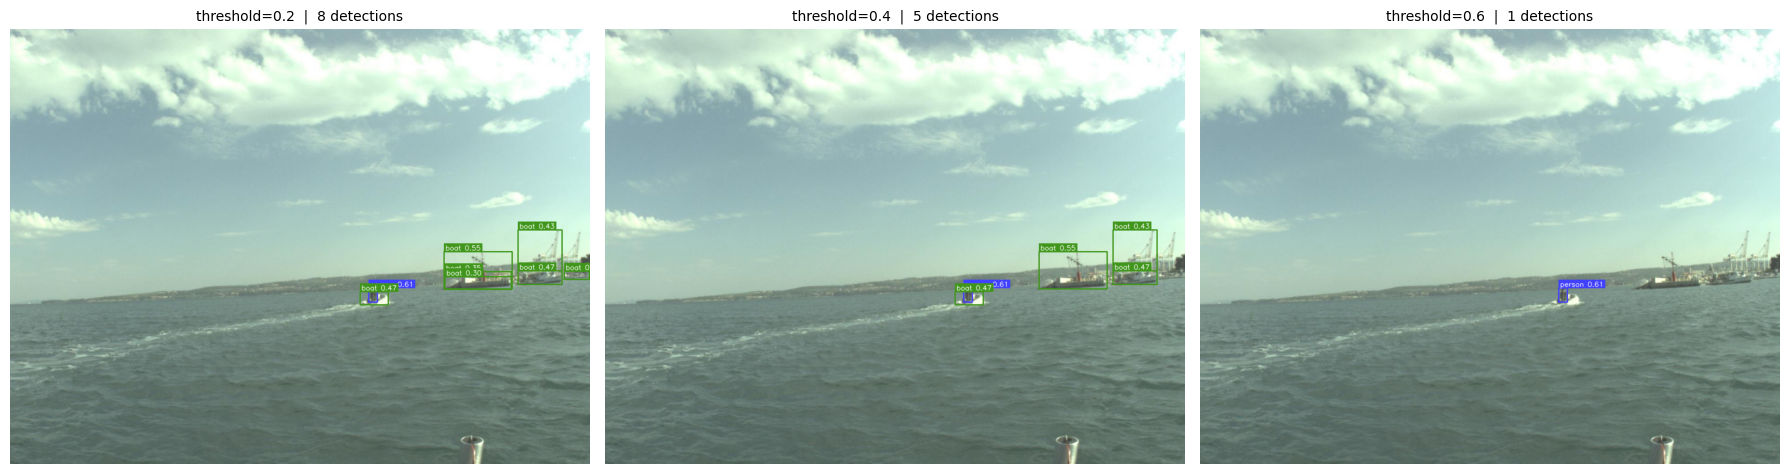

In [7]:
# Visual comparison: effect of confidence threshold on the same image
sample_img = Image.open(sample_paths[0]).convert("RGB")
thresholds = [0.2, 0.4, 0.6]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, thr in zip(axes, thresholds):
    detections = model.predict(sample_img, threshold=thr)
    labels = [
        f"{COCO_CLASSES[cid]} {conf:.2f}"
        for cid, conf in zip(detections.class_id, detections.confidence)
    ]
    img_ann = box_annotator.annotate(np.array(sample_img).copy(), detections)
    img_ann = label_annotator.annotate(img_ann, detections, labels=labels)
    ax.imshow(img_ann)
    ax.set_title(f"threshold={thr}  |  {len(detections)} detections", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

[2026-04-06 19:31:06] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-04-06 19:31:07] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.


[2026-04-06 19:31:07] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


[2026-04-06 19:31:08] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-04-06 19:31:09] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.


[2026-04-06 19:31:10] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


[2026-04-06 19:31:10] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-04-06 19:31:11] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.


[2026-04-06 19:31:12] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


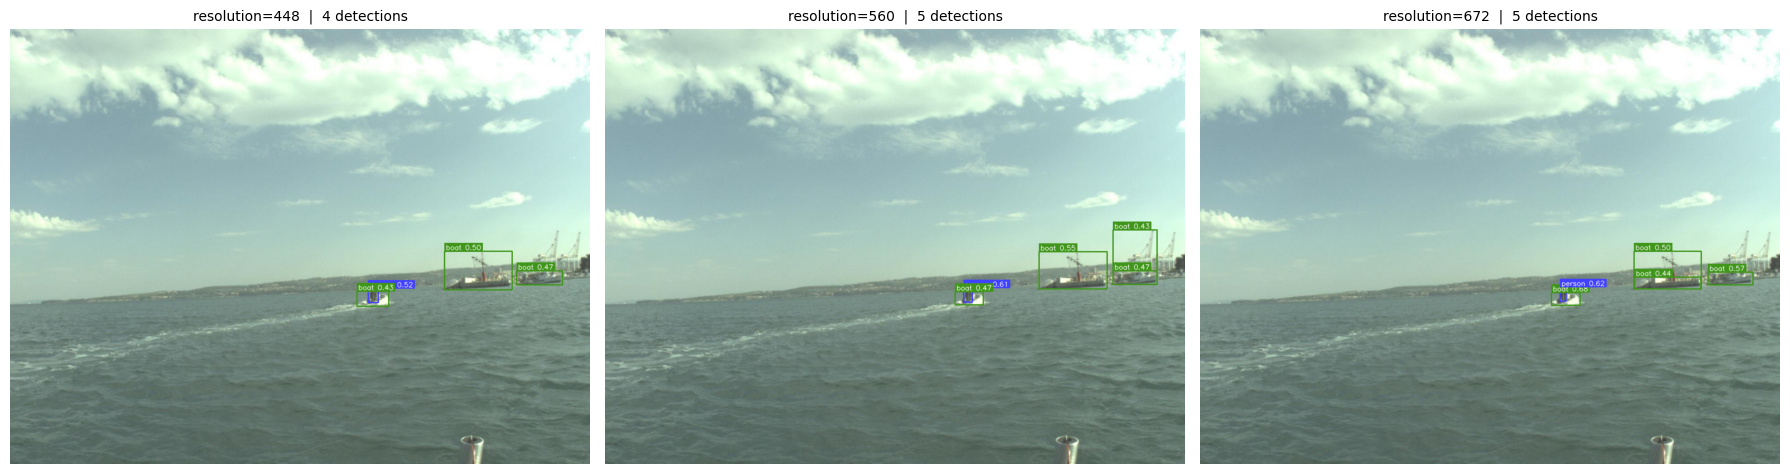

In [8]:
# Visual comparison: effect of input resolution (requires re-instantiating the model)
resolutions = [448, 560, 672]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, res in zip(axes, resolutions):
    m = RFDETRBase(resolution=res)
    detections = m.predict(sample_img, threshold=0.4)
    labels = [
        f"{COCO_CLASSES[cid]} {conf:.2f}"
        for cid, conf in zip(detections.class_id, detections.confidence)
    ]
    img_ann = box_annotator.annotate(np.array(sample_img).copy(), detections)
    img_ann = label_annotator.annotate(img_ann, detections, labels=labels)
    ax.imshow(img_ann)
    ax.set_title(f"resolution={res}  |  {len(detections)} detections", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Architecture Overview

```
Input image
    │
    ▼
┌─────────────────────────────┐
│  DINOv2 ViT Backbone        │  ← frozen or low-LR during fine-tuning
│  (ViT-S for Base, ViT-B     │    outputs multi-scale feature maps
│   for Large)                │
└────────────┬────────────────┘
             │ multi-scale features
    ▼
┌─────────────────────────────┐
│  Deformable Attention       │  ← encoder: refines features
│  Encoder                    │
└────────────┬────────────────┘
             │
    ▼
┌─────────────────────────────┐
│  Transformer Decoder        │  ← N learnable object queries attend
│  (object queries)           │    to encoder features
└────────────┬────────────────┘
             │
    ▼
┌─────────────────────────────┐
│  Detection Heads            │  ← per-query: class logits + bbox (cx,cy,w,h)
└─────────────────────────────┘
             │
    ▼
Top-k selection by confidence  ← no NMS; threshold applied here
```

**Training loss** combines:
- Classification: focal loss
- Bounding box: L1 loss + GIoU loss
- Assignment: Hungarian matching (bipartite, one prediction per GT object)

## Fine-Tuning Parameters

These are passed to `model.train()`. The table below lists every major knob with its default value and guidance for our LARS dataset.

| Parameter | Default | Notes |
|---|---|---|
| `dataset_dir` | — | Path to COCO-formatted dataset root (see §9) |
| `epochs` | 50 | 20–50 is usually sufficient for fine-tuning |
| `batch_size` | 4 | Per-GPU batch size; keep low if GPU memory is limited |
| `grad_accum_steps` | 4 | Effective batch = `batch_size × grad_accum_steps` (target ≥16) |
| `lr` | 1e-4 | Learning rate for decoder + heads |
| `lr_encoder` | 1.5e-5 | Learning rate for DINOv2 backbone (10× lower — slow fine-tuning) |
| `resolution` | 560 | Input resolution; must be a multiple of 56 |
| `weight_decay` | 1e-4 | L2 regularisation |
| `grad_clip_max_norm` | 0.1 | Gradient clipping — important for transformer stability |
| `checkpoint_interval` | 10 | Save a checkpoint every N epochs |
| `num_select` | 300 | Number of top queries kept at inference |
| `eos_coeff` | 0.1 | Weight of the "no object" class in the loss — lower = more detections |
| `warmup_epochs` | 0 | LR warmup epochs; setting 1–3 can help stability |

### Recommended starting config for LARS fine-tuning

```python
model.train(
    dataset_dir  = "../Data/lars_processed",
    epochs       = 40,
    batch_size   = 4,
    grad_accum_steps = 4,   # effective batch size = 16
    lr           = 1e-4,
    lr_encoder   = 1e-5,    # keep backbone changes small
    resolution   = 560,
    weight_decay = 1e-4,
    grad_clip_max_norm = 0.1,
    checkpoint_interval = 5,
)
```

In [9]:
# Inspect default training config without launching a run
import inspect
sig = inspect.signature(model.train)
print("model.train() parameters and defaults:\n")
for name, param in sig.parameters.items():
    default = param.default if param.default is not inspect.Parameter.empty else "(required)"
    print(f"  {name:<25} {default}")

model.train() parameters and defaults:

  kwargs                    (required)


## Dataset Preparation for Fine-Tuning

RF-DETR expects the dataset in **COCO format** with a specific folder layout:

```
dataset_dir/
  train/
    images/
    _annotations.coco.json
  valid/
    images/
    _annotations.coco.json
  test/           ← optional
    images/
    _annotations.coco.json
```

Our `datasplit.py` output at `Data/lars_processed/` already has the right COCO JSON structure, but two things need adjusting before fine-tuning:

1. **Rename the validation folder**: `val/` → `valid/`
2. **Rename the annotation file** in each split: `annotations.json` → `_annotations.coco.json`

The cell below performs these renames (safe to re-run — skips if already done).

In [10]:
import shutil

# 1. Rename val → valid
val_path   = DATA_ROOT / "val"
valid_path = DATA_ROOT / "valid"
if val_path.exists() and not valid_path.exists():
    val_path.rename(valid_path)
    print("Renamed: val/ → valid/")
else:
    print("val/ → valid/ already done or val/ missing, skipping")

# 2. Rename annotations.json → _annotations.coco.json in each split
for split in ("train", "valid", "test"):
    src = DATA_ROOT / split / "annotations.json"
    dst = DATA_ROOT / split / "_annotations.coco.json"
    if src.exists() and not dst.exists():
        src.rename(dst)
        print(f"Renamed: {split}/annotations.json → {split}/_annotations.coco.json")
    else:
        print(f"{split}: already renamed or source missing, skipping")

print("\nDataset structure ready for RF-DETR fine-tuning.")

val/ → valid/ already done or val/ missing, skipping
train: already renamed or source missing, skipping
valid: already renamed or source missing, skipping
test: already renamed or source missing, skipping

Dataset structure ready for RF-DETR fine-tuning.


## First Training Test Run

A 5-epoch smoke test to validate the fine-tuning pipeline end-to-end before committing to a full run.

**Goals**
- Confirm the model trains without errors on our COCO-formatted LARS data
- Observe early loss curves to check the training signal is healthy
- Compare pretrained vs. fine-tuned inference on a held-out sample

**Dataset recap**: 2 250 train images · 355 valid images · 8 obstacle categories

In [11]:
import json

# Quick dataset recap
for split in ("train", "valid"):
    ann = json.load(open(DATA_ROOT / split / "_annotations.coco.json"))
    print(f"{split:6s}: {len(ann['images']):4d} images | {len(ann['annotations']):5d} annotations")

ann_train = json.load(open(DATA_ROOT / "train" / "_annotations.coco.json"))
print(f"\nClasses ({len(ann_train['categories'])}):")
for cat in ann_train["categories"]:
    print(f"  [{cat['id']:2d}] {cat['name']}")

train : 2102 images |  7761 annotations
valid :  198 images |  1107 annotations

Classes (8):
  [11] Boat/ship
  [12] Row boats
  [13] Paddle board
  [14] Buoy
  [15] Swimmer
  [16] Animal
  [17] Float
  [19] Other


### Training configuration (smoke test)

| Parameter | Value | Rationale |
|---|---|---|
| `epochs` | 5 | Just enough to confirm healthy loss curves |
| `batch_size` | 4 | Safe for most 6–8 GB GPUs |
| `grad_accum_steps` | 4 | Effective batch = 16 |
| `lr` | 1e-4 | Decoder / head learning rate |
| `lr_encoder` | 1e-5 | Backbone — 10× lower to preserve pretrained features |
| `resolution` | 560 | DINOv2 default; good balance for maritime scenes |
| `checkpoint_interval` | 5 | Save at end of test run |

> **Note on category IDs**: LARS categories use non-contiguous IDs (11–17, 19). COCO format supports arbitrary IDs, so RF-DETR handles this correctly — no remapping needed.

In [18]:
import torch
import random as _random
import numpy as _np

# Reproducibility
_random.seed(4)
_np.random.seed(4)
torch.manual_seed(4)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(4)

print(f"Device: {'CUDA — ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

OUTPUT_DIR = Path("../runs/rfdetr_test_run")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Resume from the best checkpoint if one already exists
_resume_ckpt = OUTPUT_DIR / "checkpoint_best_total.pth"
if not _resume_ckpt.exists():
    _candidates = sorted(OUTPUT_DIR.glob("checkpoint*.pth"))
    _resume_ckpt = _candidates[-1] if _candidates else None

if _resume_ckpt:
    print(f"Resuming from: {_resume_ckpt.name}")
else:
    print("No checkpoint found — training from COCO pretrained weights.")

model_ft = RFDETRBase(resolution=560)

model_ft.train(
    dataset_dir          = str(DATA_ROOT),
    epochs               = 10,
    batch_size           = 4,
    grad_accum_steps     = 4,
    lr                   = 1e-4,
    lr_encoder           = 1e-5,
    resolution           = 560,
    weight_decay         = 1e-4,
    grad_clip_max_norm   = 0.1,
    checkpoint_interval  = 5,
    output_dir           = str(OUTPUT_DIR),
    resume               = str(_resume_ckpt) if _resume_ckpt else None,
)
print("Training complete. Checkpoints saved to:", OUTPUT_DIR)

Device: CUDA — NVIDIA GeForce RTX 4080 Laptop GPU
Resuming from: checkpoint_best_total.pth
[2026-04-06 21:45:13] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-04-06 21:45:14] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-04-06 21:45:15] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.


[2026-04-06 21:45:16] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 8. The detection head will be re-initialized to 8 classes.
[2026-04-06 21:45:16] [WARNING] rf-detr - TensorBoard logging disabled: Neither `tensorboard` nor `tensorboardX` is available. Try `pip install`ing either.
Requirement 'tensorboardX' not met. HINT: Try running `pip install -U 'tensorboardX'`
Requirement 'tensorboard' not met. HINT: Try running `pip install -U 'tensorboard'`. Install with: pip install tensorboard
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[2026-04-06 21:45:16] [INFO] rf-detr - Building Roboflow train dataset with square resize at resolution 560
[2026-04-06 21:45:16] [INFO] rf-detr - Using multi-scale training with square resize and scales: [840]
[2026-04-06 21:45:16] [INFO] rf-detr - Built 1 Albumentations transforms from config
[2026-04-06 21:45:16] [INFO] rf-detr - Built 1 Albumentations transforms from config


c:\Users\TimPr\allcode\AP2026-Maritime-Navigation\apenv\lib\site-packages\lightning_fabric\loggers\csv_logs.py:268: Experiment logs directory C:\Users\TimPr\allcode\AP2026-Maritime-Navigation\runs\rfdetr_test_run\ exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!


loading annotations into memory...
Done (t=0.27s)
creating index...
index created!
[2026-04-06 21:45:16] [INFO] rf-detr - Building Roboflow val dataset with square resize at resolution 560
[2026-04-06 21:45:16] [INFO] rf-detr - Using multi-scale training with square resize and scales: [840]
[2026-04-06 21:45:16] [INFO] rf-detr - Built 1 Albumentations transforms from config


...

[2026-04-06 22:02:24] [INFO] rf-detr - Best EMA mAP improved to 0.2704 (epoch 7)


[2026-04-06 22:09:05] [INFO] rf-detr - Best regular mAP saved to C:\Users\TimPr\allcode\AP2026-Maritime-Navigation\runs\rfdetr_test_run\checkpoint_best_regular.pth (epoch 8)


[2026-04-06 22:15:07] [INFO] rf-detr - Best regular mAP saved to C:\Users\TimPr\allcode\AP2026-Maritime-Navigation\runs\rfdetr_test_run\checkpoint_best_regular.pth (epoch 9)
[2026-04-06 22:15:07] [INFO] rf-detr - Best EMA mAP improved to 0.2733 (epoch 9)


`Trainer.fit` stopped: `max_epochs=10` reached.


[2026-04-06 22:15:13] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.2609, ema=0.2733)
Training complete. Checkpoints saved to: ..\runs\rfdetr_test_run


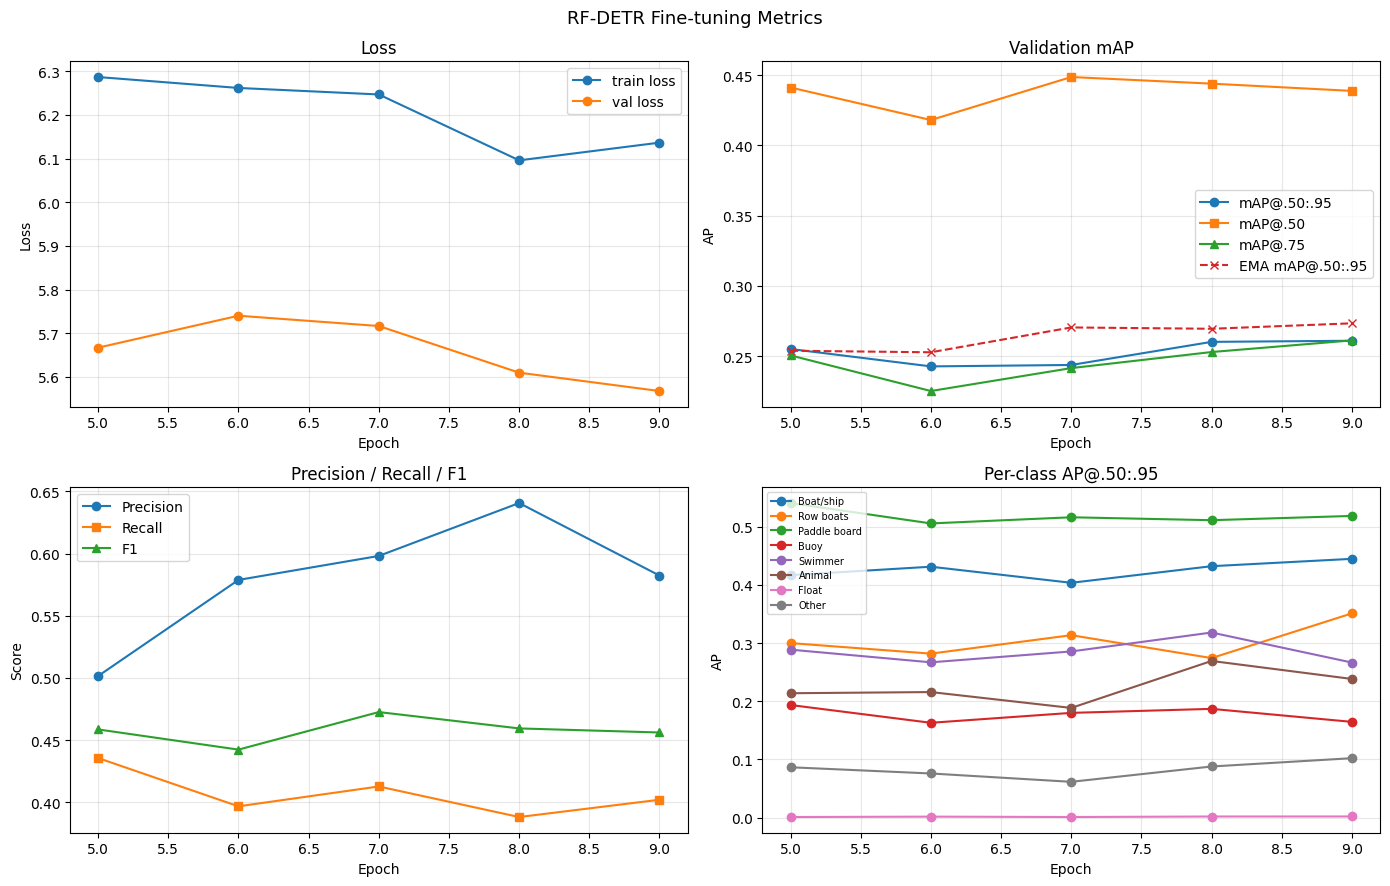

Best epoch: 9
  mAP@.50:.95 = 0.2609
  mAP@.50     = 0.4387
  Precision   = 0.5823
  Recall      = 0.4019
  F1          = 0.4560


: 

In [ ]:
import pandas as pd

metrics_path = OUTPUT_DIR / "metrics.csv"
if not metrics_path.exists():
    print("metrics.csv not found — has training run yet?")
else:
    df = pd.read_csv(metrics_path)

    # Epoch-end val rows have mAP filled; epoch-end train rows have train/loss filled.
    # Keep one row per epoch for each.
    val_df   = df.dropna(subset=["val/mAP_50_95"]).copy()
    train_df = df.dropna(subset=["train/loss"]).copy()

    # Merge on epoch so we get train loss alongside val metrics
    merged = pd.merge(
        val_df[["epoch", "val/loss", "val/mAP_50_95", "val/mAP_50", "val/mAP_75",
                "val/ema_mAP_50_95", "val/precision", "val/recall", "val/F1",
                "val/AP/Boat/ship", "val/AP/Row boats", "val/AP/Paddle board",
                "val/AP/Buoy", "val/AP/Swimmer", "val/AP/Animal",
                "val/AP/Float", "val/AP/Other"]],
        train_df[["epoch", "train/loss"]],
        on="epoch", how="left"
    ).sort_values("epoch").reset_index(drop=True)

    epochs = merged["epoch"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # -- Loss --
    ax = axes[0, 0]
    ax.plot(epochs, merged["train/loss"], marker="o", label="train loss")
    ax.plot(epochs, merged["val/loss"],   marker="o", label="val loss")
    ax.set_title("Loss"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(True, alpha=0.3)

    # -- mAP --
    ax = axes[0, 1]
    ax.plot(epochs, merged["val/mAP_50_95"],     marker="o", label="mAP@.50:.95")
    ax.plot(epochs, merged["val/mAP_50"],         marker="s", label="mAP@.50")
    ax.plot(epochs, merged["val/mAP_75"],         marker="^", label="mAP@.75")
    ax.plot(epochs, merged["val/ema_mAP_50_95"],  marker="x", linestyle="--", label="EMA mAP@.50:.95")
    ax.set_title("Validation mAP"); ax.set_xlabel("Epoch"); ax.set_ylabel("AP")
    ax.legend(); ax.grid(True, alpha=0.3)

    # -- Precision / Recall / F1 --
    ax = axes[1, 0]
    ax.plot(epochs, merged["val/precision"], marker="o", label="Precision")
    ax.plot(epochs, merged["val/recall"],    marker="s", label="Recall")
    ax.plot(epochs, merged["val/F1"],        marker="^", label="F1")
    ax.set_title("Precision / Recall / F1"); ax.set_xlabel("Epoch"); ax.set_ylabel("Score")
    ax.legend(); ax.grid(True, alpha=0.3)

    # -- Per-class AP --
    ax = axes[1, 1]
    class_cols = [c for c in merged.columns if c.startswith("val/AP/")]
    for col in class_cols:
        ax.plot(epochs, merged[col], marker="o", label=col.replace("val/AP/", ""))
    ax.set_title("Per-class AP@.50:.95"); ax.set_xlabel("Epoch"); ax.set_ylabel("AP")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    plt.suptitle("RF-DETR Fine-tuning Metrics", fontsize=13)
    plt.tight_layout()
    plt.show()

    # Summary table
    best_epoch = merged.loc[merged["val/mAP_50_95"].idxmax(), "epoch"]
    best = merged[merged["epoch"] == best_epoch].iloc[0]
    print(f"Best epoch: {int(best_epoch)}")
    print(f"  mAP@.50:.95 = {best['val/mAP_50_95']:.4f}")
    print(f"  mAP@.50     = {best['val/mAP_50']:.4f}")
    print(f"  Precision   = {best['val/precision']:.4f}")
    print(f"  Recall      = {best['val/recall']:.4f}")
    print(f"  F1          = {best['val/F1']:.4f}")

### Post-training inference comparison

Side-by-side: COCO-pretrained (left) vs. LARS fine-tuned (right) on the same images.
The fine-tuned model should start predicting LARS category names instead of COCO ones.

Loading checkpoint: checkpoint_best_total.pth


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

[2026-04-06 23:20:36] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


Checkpoint loaded.


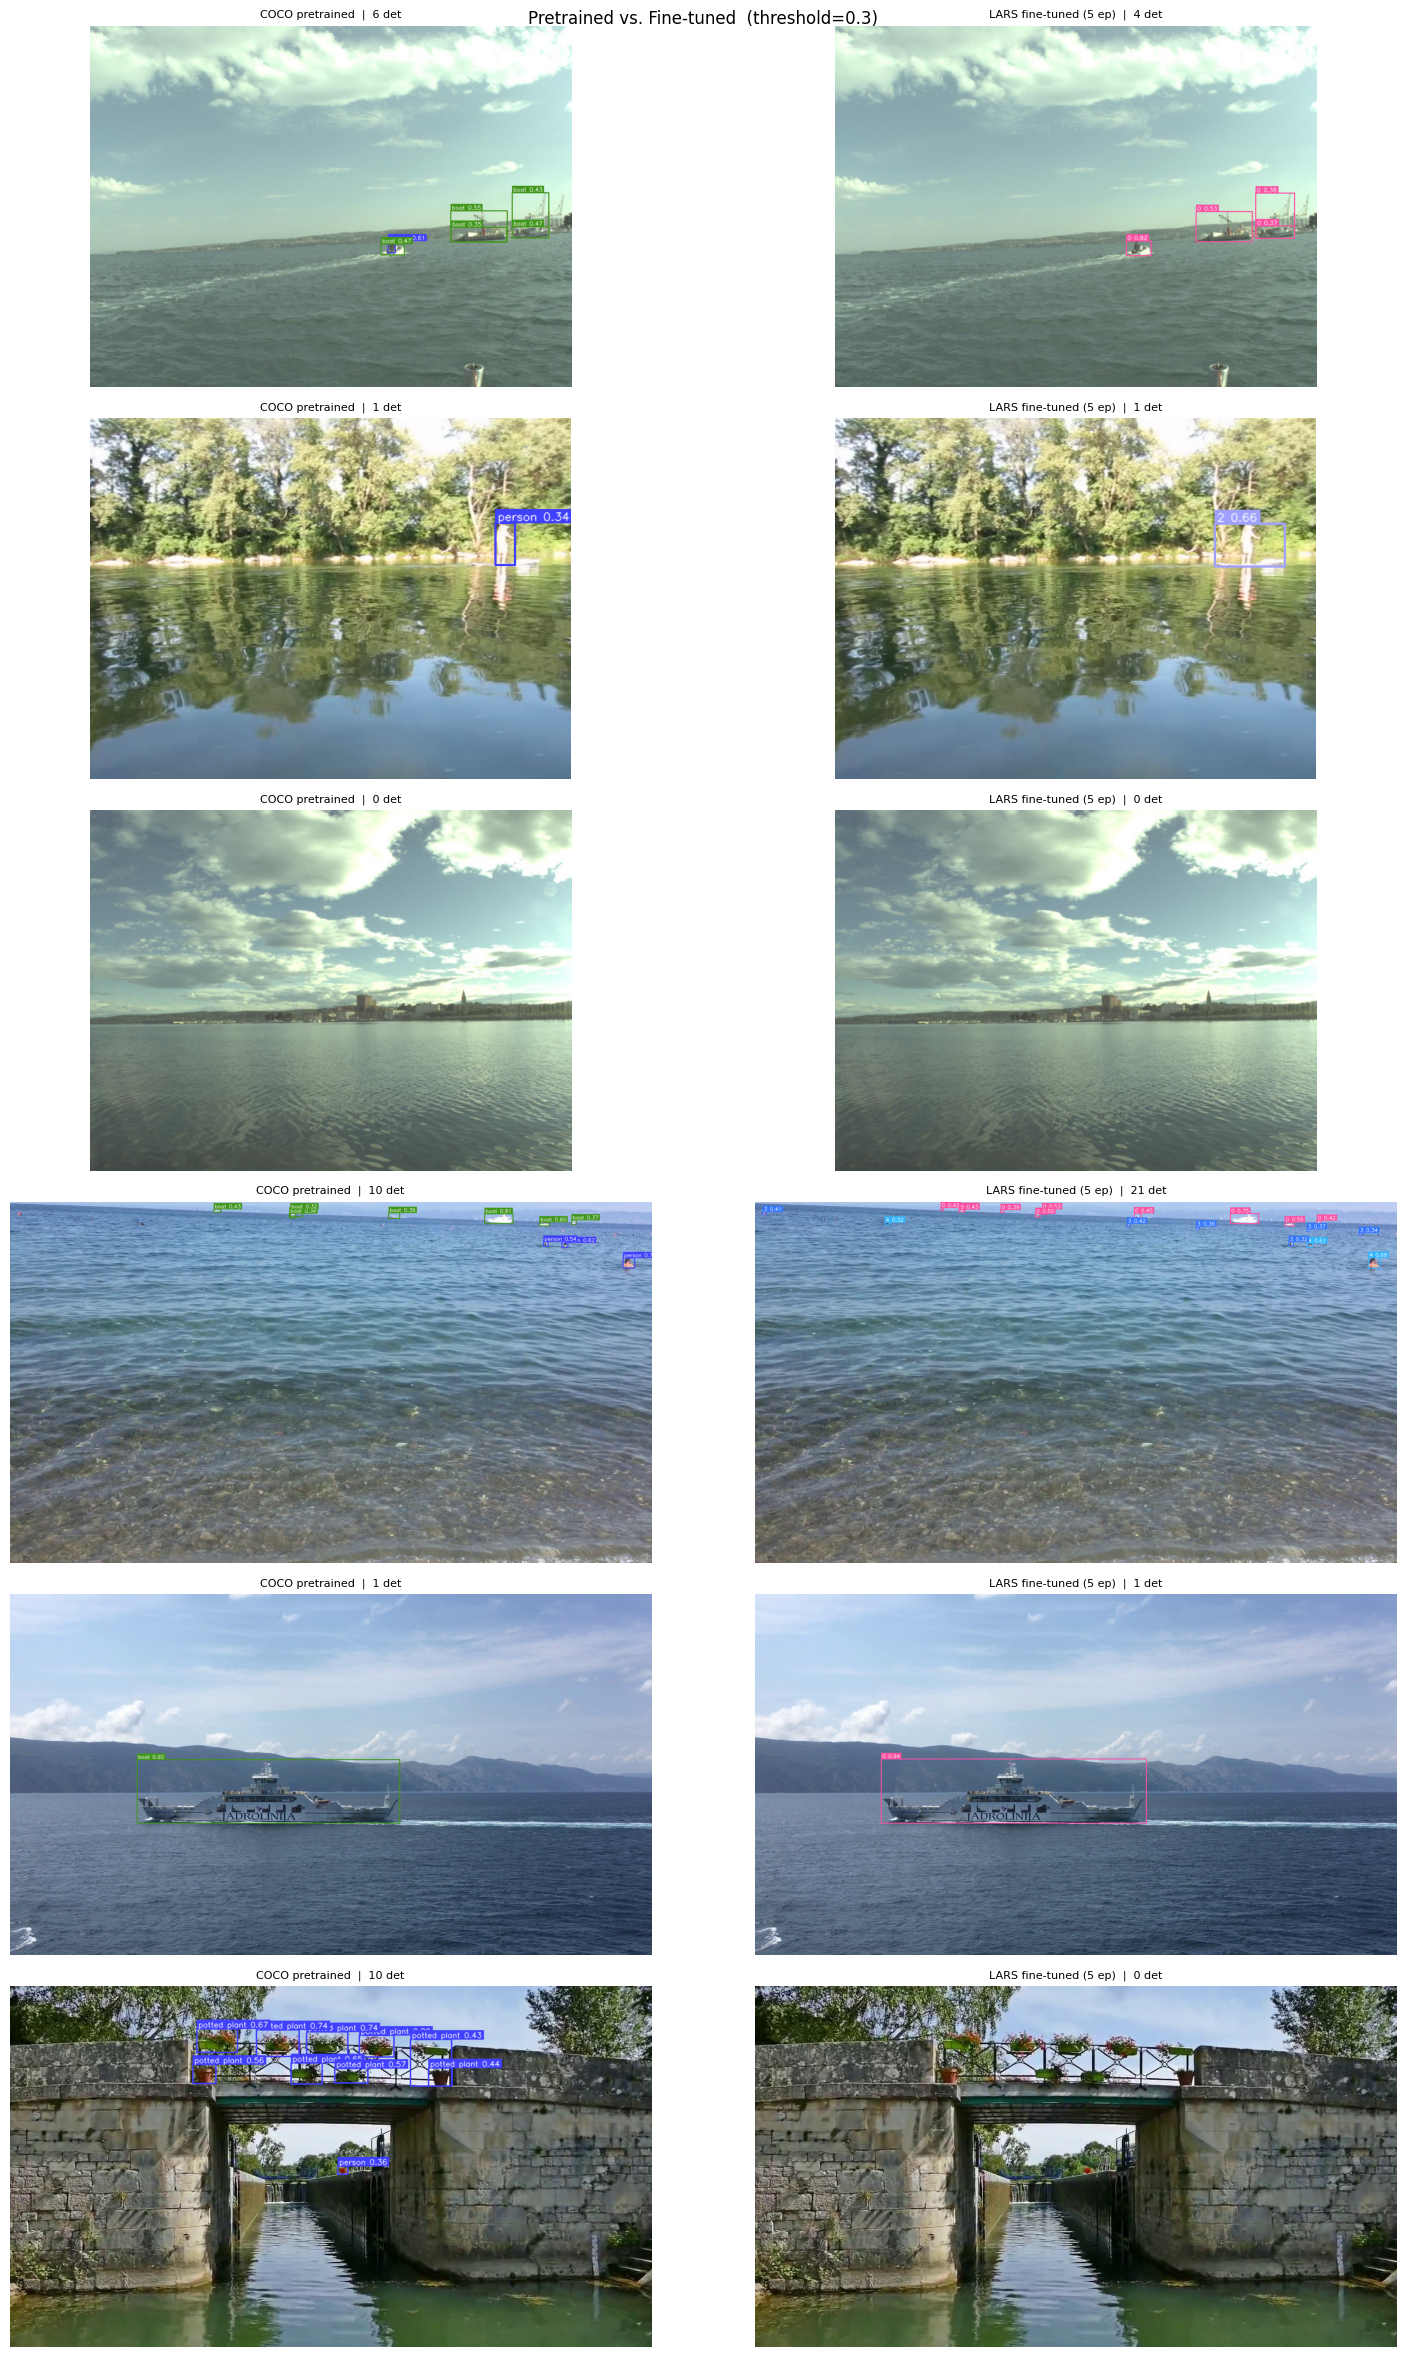

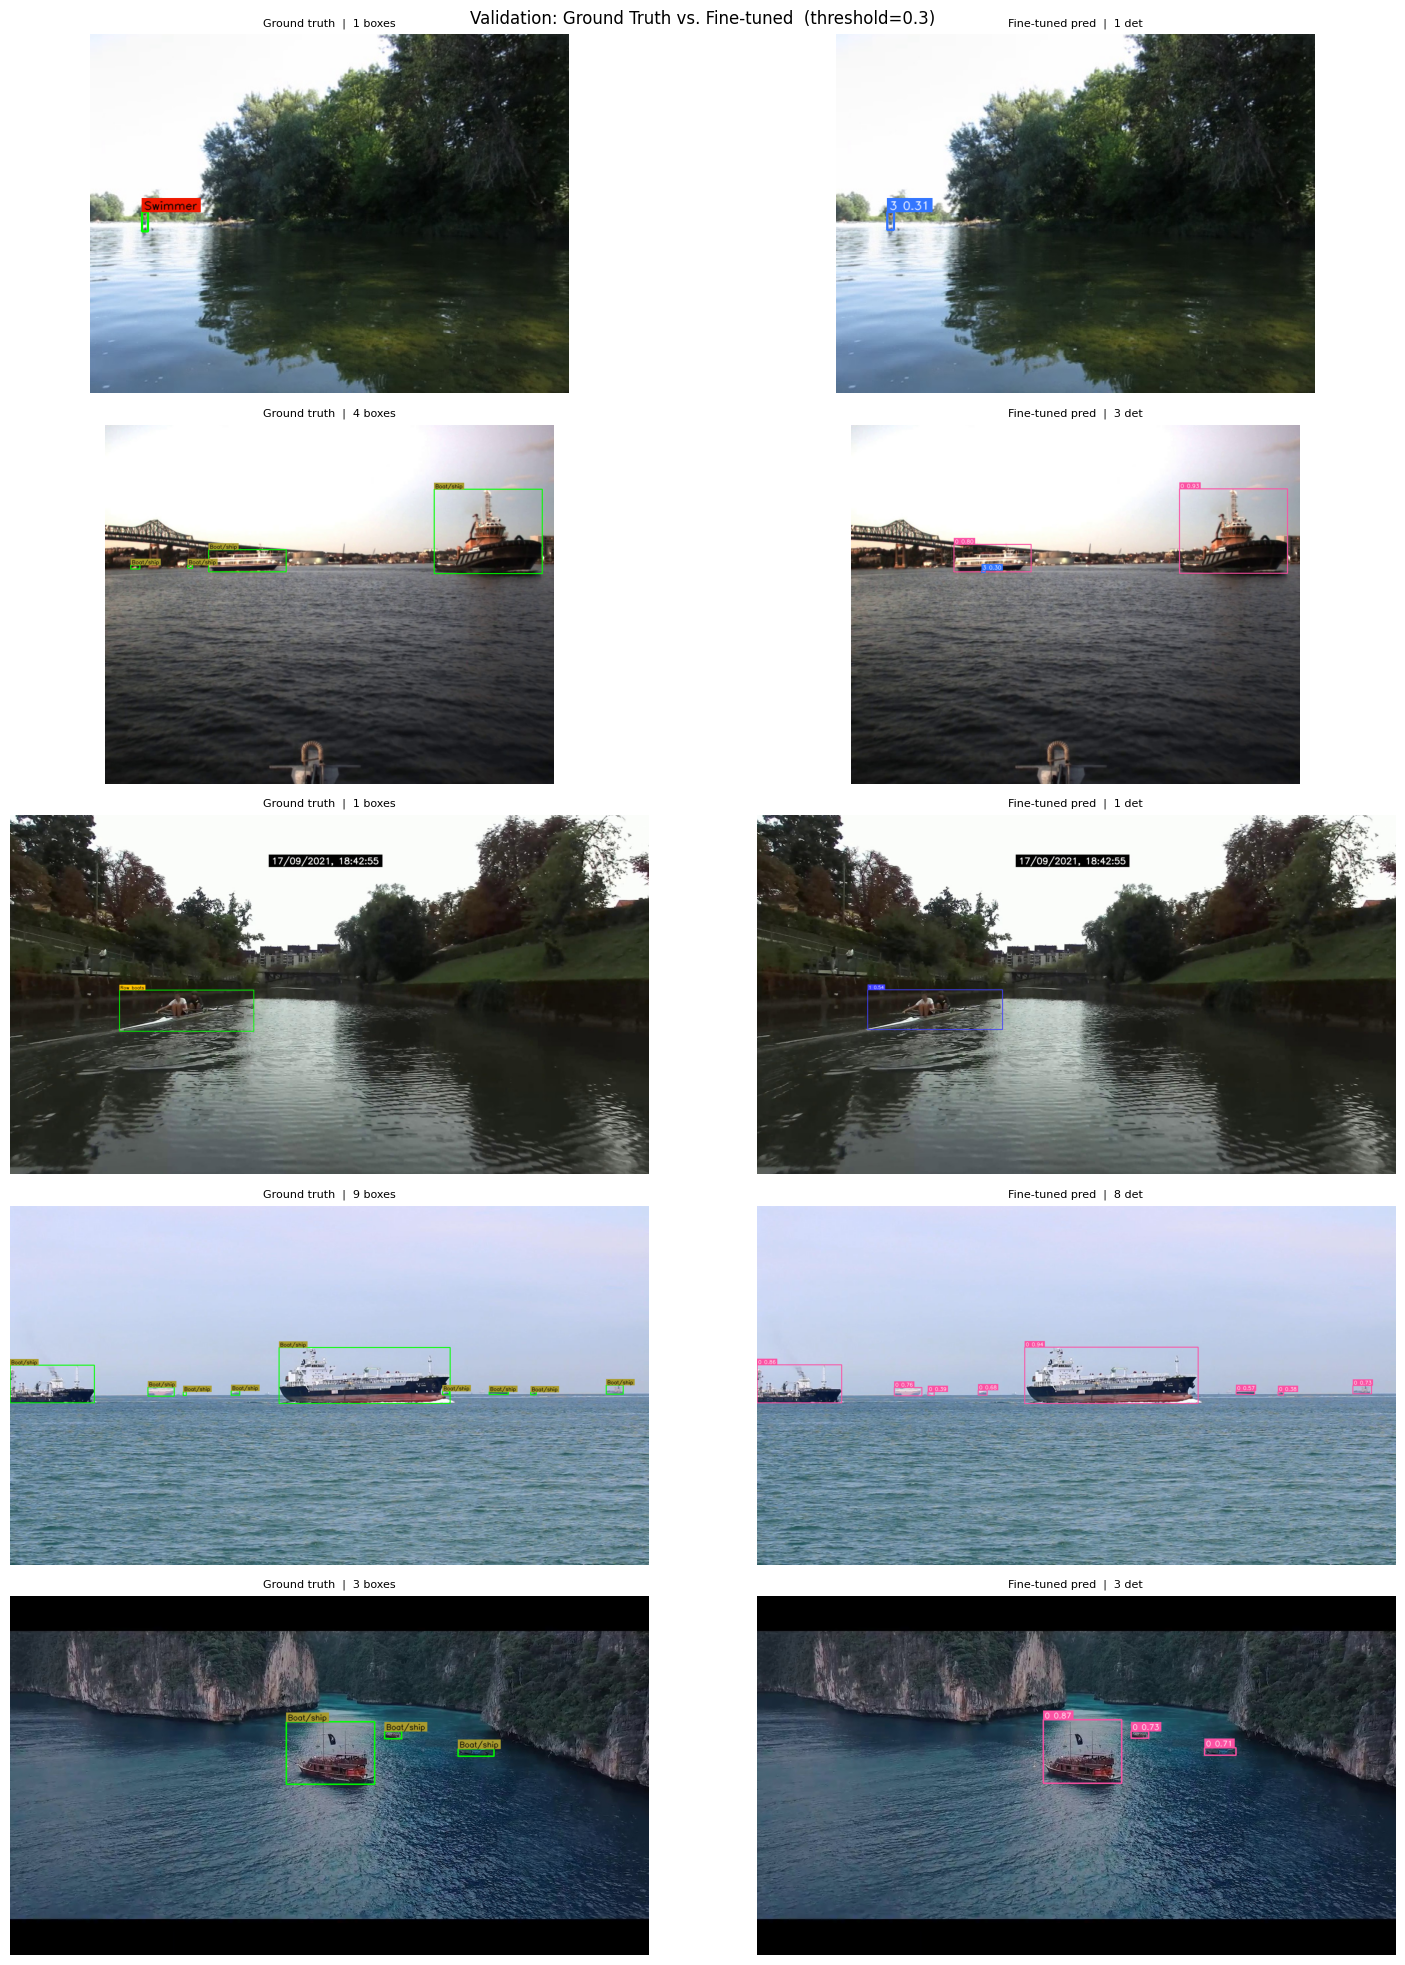

In [21]:
# Load the best checkpoint from the test run
best_ckpt = OUTPUT_DIR / "checkpoint_best_total.pth"
if not best_ckpt.exists():
    # Fall back to last checkpoint
    ckpts = sorted(OUTPUT_DIR.glob("checkpoint*.pth"))
    best_ckpt = ckpts[-1] if ckpts else None

if best_ckpt is None:
    raise FileNotFoundError("No checkpoint found in OUTPUT_DIR — did training complete?")

print(f"Loading checkpoint: {best_ckpt.name}")
model_ft_eval = RFDETRBase(resolution=560, num_classes=8, pretrain_weights=None)
model_ft_eval.model.model.load_state_dict(torch.load(best_ckpt, map_location="cpu")["model"])
print("Checkpoint loaded.")

# Class names for the fine-tuned model (from train annotations)
LARS_CLASSES = {cat["id"]: cat["name"] for cat in ann_train["categories"]}

# Use the same sample images as the pretrained inference section
COMPARE_THRESHOLD = 0.3

fig, axes = plt.subplots(len(sample_paths), 2, figsize=(16, 4 * len(sample_paths)))

for row, img_path in enumerate(sample_paths):
    pil_img = Image.open(img_path).convert("RGB")
    arr = np.array(pil_img)

    # --- Pretrained (COCO) ---
    det_coco = model.predict(pil_img, threshold=COMPARE_THRESHOLD)
    labels_coco = [f"{COCO_CLASSES[cid]} {conf:.2f}"
                   for cid, conf in zip(det_coco.class_id, det_coco.confidence)]
    ann_coco = box_annotator.annotate(arr.copy(), det_coco)
    ann_coco = label_annotator.annotate(ann_coco, det_coco, labels=labels_coco)

    # --- Fine-tuned (LARS) ---
    det_lars = model_ft_eval.predict(pil_img, threshold=COMPARE_THRESHOLD)
    labels_lars = [f"{LARS_CLASSES.get(cid, cid)} {conf:.2f}"
                   for cid, conf in zip(det_lars.class_id, det_lars.confidence)]
    ann_lars = box_annotator.annotate(arr.copy(), det_lars)
    ann_lars = label_annotator.annotate(ann_lars, det_lars, labels=labels_lars)

    axes[row, 0].imshow(ann_coco)
    axes[row, 0].set_title(f"COCO pretrained  |  {len(det_coco)} det", fontsize=8)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(ann_lars)
    axes[row, 1].set_title(f"LARS fine-tuned (5 ep)  |  {len(det_lars)} det", fontsize=8)
    axes[row, 1].axis("off")

plt.suptitle(f"Pretrained vs. Fine-tuned  (threshold={COMPARE_THRESHOLD})", fontsize=12)
plt.tight_layout()
plt.show()

# ── Validation GT vs. fine-tuned predictions ──────────────────────────────────
import random as _random

ann_val = json.load(open(DATA_ROOT / "valid" / "_annotations.coco.json"))

# Build per-image annotation lookup
val_img_meta   = {img["id"]: img for img in ann_val["images"]}
val_ann_by_id  = {}
for a in ann_val["annotations"]:
    val_ann_by_id.setdefault(a["image_id"], []).append(a)
VAL_CAT_NAMES  = {cat["id"]: cat["name"] for cat in ann_val["categories"]}

# Sample val images that have at least one annotation
val_with_ann = [img_id for img_id, anns in val_ann_by_id.items() if anns]
_random.seed(4)
val_sample_ids = _random.sample(val_with_ann, min(5, len(val_with_ann)))

fig2, axes2 = plt.subplots(len(val_sample_ids), 2, figsize=(16, 4 * len(val_sample_ids)))
gt_box_ann   = sv.BoxAnnotator(color=sv.Color.GREEN, thickness=2)
gt_lbl_ann   = sv.LabelAnnotator(text_scale=0.5, text_padding=3, text_color=sv.Color.BLACK)

for row, img_id in enumerate(val_sample_ids):
    meta    = val_img_meta[img_id]
    img_path = DATA_ROOT / "valid" / meta["file_name"]
    pil_img = Image.open(img_path).convert("RGB")
    arr     = np.array(pil_img)

    # Ground-truth boxes (COCO xywh -> xyxy)
    gt_anns  = val_ann_by_id.get(img_id, [])
    gt_xyxy  = np.array([[a["bbox"][0], a["bbox"][1],
                           a["bbox"][0] + a["bbox"][2],
                           a["bbox"][1] + a["bbox"][3]] for a in gt_anns], dtype=float)
    gt_cids  = np.array([a["category_id"] for a in gt_anns])
    gt_det   = sv.Detections(xyxy=gt_xyxy, class_id=gt_cids)
    gt_lbls  = [VAL_CAT_NAMES.get(cid, str(cid)) for cid in gt_cids]
    ann_gt   = gt_box_ann.annotate(arr.copy(), gt_det)
    ann_gt   = gt_lbl_ann.annotate(ann_gt, gt_det, labels=gt_lbls)

    # Fine-tuned predictions
    det_ft   = model_ft_eval.predict(pil_img, threshold=COMPARE_THRESHOLD)
    ft_lbls  = [f"{LARS_CLASSES.get(cid, cid)} {conf:.2f}"
                for cid, conf in zip(det_ft.class_id, det_ft.confidence)]
    ann_ft   = box_annotator.annotate(arr.copy(), det_ft)
    ann_ft   = label_annotator.annotate(ann_ft, det_ft, labels=ft_lbls)

    axes2[row, 0].imshow(ann_gt)
    axes2[row, 0].set_title(f"Ground truth  |  {len(gt_anns)} boxes", fontsize=8)
    axes2[row, 0].axis("off")

    axes2[row, 1].imshow(ann_ft)
    axes2[row, 1].set_title(f"Fine-tuned pred  |  {len(det_ft)} det", fontsize=8)
    axes2[row, 1].axis("off")

plt.suptitle(f"Validation: Ground Truth vs. Fine-tuned  (threshold={COMPARE_THRESHOLD})", fontsize=12)
plt.tight_layout()
plt.show()